In [1]:
import os, pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
import networkx as nx
#df = pd.read_pickle(os.getenv("PPI_DB_PATH"))
data_path = "../../flatten/processed-data/20251023-s288c-annotated-PPI-net.pkl"
df = pd.read_pickle(data_path)
edge_path = "../../0-download-inputs/data-files/The_Yeast_Interactome_edges.csv"
edges = pd.read_csv(edge_path)
u_col, v_col = "source", "target"  # <-- adjust if needed

# Ensure node IDs are strings
edges[u_col] = edges[u_col].astype(str)
edges[v_col] = edges[v_col].astype(str)

# --- Build graph ---
G = nx.from_pandas_edgelist(edges, u_col, v_col)

print(f"Loaded {len(df)} records from {data_path}")
df.head()
y2h = pd.read_csv("../../18-Y2H-data/processed-data/Y2H-s288c-step18.csv")
needed = df[["disorder_fraction", "node"]]
y2h = y2h.merge(needed, how="left", on="node")

Loaded 3927 records from ../../flatten/processed-data/20251023-s288c-annotated-PPI-net.pkl


In [2]:
# Degree (number of edges) for each node in the graph
deg_dict = dict(G.degree())

# Map degrees onto your annotation DataFrame
df["degree"] = df["node"].map(deg_dict).fillna(0).astype(int)

# Only consider nodes that actually appear in the graph (degree > 0)
deg_nonzero = df.loc[df["degree"] > 0, "degree"]

# 90th percentile degree value
top10_thresh = deg_nonzero.quantile(0.9)

print("Top-10% degree threshold:", top10_thresh)

# Top 10% by degree (ties at the threshold included)
df["is_top10_degree"] = df["degree"] >= top10_thresh

# End nodes: degree == 1
df["is_end_node"] = df["degree"] == 1

# Optional: a single categorical label
def classify_degree(row):
    if row["is_top10_degree"]:
        return "top10"
    elif row["is_end_node"]:
        return "end"
    else:
        return "other"

df["degree_class"] = df.apply(classify_degree, axis=1)

top10 = df[df["is_top10_degree"]].copy()
end_nodes = df[df["is_end_node"]].copy()

print("Top 10% nodes:", top10.shape[0])
print("End nodes:", end_nodes.shape[0])

Top-10% degree threshold: 46.40000000000009
Top 10% nodes: 393
End nodes: 663


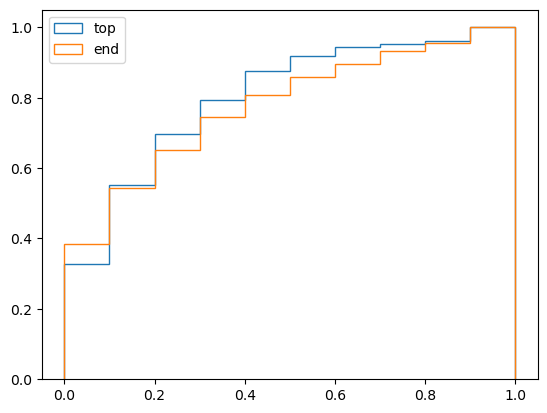

In [3]:
#print(list(top10.columns))
#print(list(end_nodes.columns))
plt.clf()
plt.hist(top10["disorder_fraction"], density=True, histtype="step", label="top", cumulative=True)
plt.hist(end_nodes["disorder_fraction"], density=True, histtype="step", label="end", cumulative=True)
plt.legend()

In [4]:
list(df.columns)

['node',
 '_wkshell',
 'degree_centrality',
 'betweenness_centrality',
 'eigenvector_centrality',
 'closeness_centrality',
 'load_centrality',
 'pagerank',
 'information_centrality',
 'CentralityCosDist_rank',
 'CentralityCosDist_similarity_score',
 'has_verified_sequence',
 'sequence',
 'UniProtKB-AC',
 'DeepTMHMM_trimmed_sequence',
 'DeepTMHMM_class',
 'cleavage_site_start',
 'signalP_trimmed_sequence',
 'ProteinName',
 'GO_terms',
 'GO_terms_human_readable',
 'localization_keywords',
 'parsed_functions',
 'parsed_PTMs',
 'ptm_bronze',
 'ptm_gold',
 'ptm_silver',
 'IDR_count',
 'IDR_sequences',
 'IDR_ranges',
 'N_aa_disordered',
 'disorder_fraction',
 'is_disordered_0.05',
 'is_disordered_0.10',
 'is_disordered_0.15',
 'is_disordered_0.20',
 'is_disordered_0.25',
 'is_disordered_0.30',
 'is_disordered_0.35',
 'is_disordered_0.40',
 'is_disordered_0.45',
 'is_disordered_0.50',
 'is_disordered_0.55',
 'is_disordered_0.60',
 'is_disordered_0.65',
 'is_disordered_0.70',
 'is_disordered_0

In [5]:
df["degree_centrality"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 3927 entries, 0 to 3926
Series name: degree_centrality
Non-Null Count  Dtype  
--------------  -----  
3927 non-null   float64
dtypes: float64(1)
memory usage: 30.8 KB


In [6]:
cut = np.percentile(df["degree_centrality"], 90)
top10 = df[df["degree_centrality"] >= cut]
bottom90 = df[df["degree_centrality"] < cut]

cut = np.percentile(y2h["degree_centrality"], 90)
y2h_top10 = y2h[y2h["degree_centrality"] >= cut]
y2h_bottom90 = y2h[y2h["degree_centrality"] < cut]

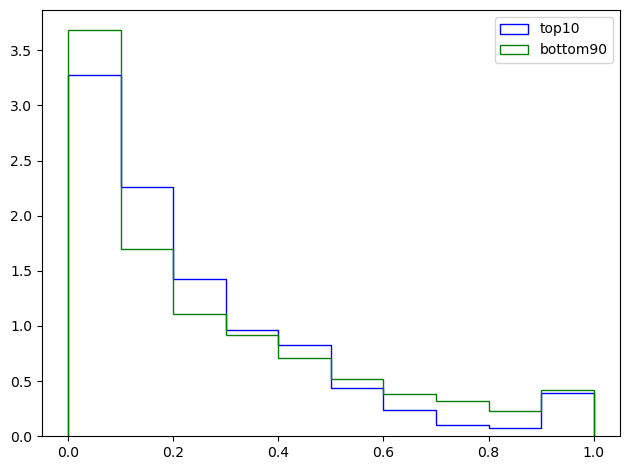

In [7]:
plt.clf()
top_vals = top10["disorder_fraction"].dropna()
bottom_vals = bottom90["disorder_fraction"].dropna()

plt.hist(top_vals, color="blue", label="top10", density=True, histtype="step")
plt.hist(bottom_vals, color="green", label="bottom90", density=True, histtype="step")
plt.legend()
plt.tight_layout()
plt.show()

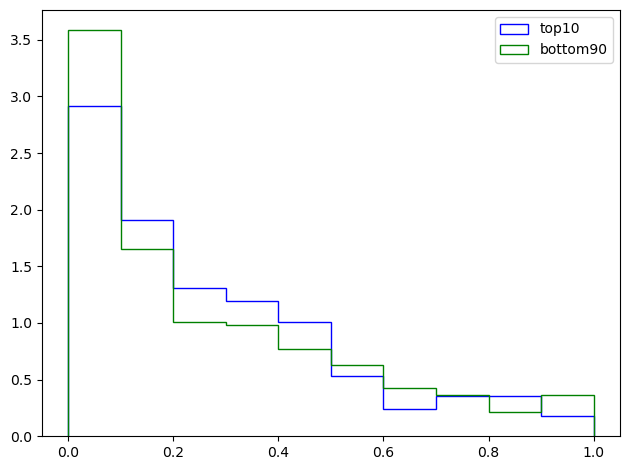

In [41]:
plt.clf()
top_vals = y2h_top10["disorder_fraction"].dropna()
bottom_vals = y2h_bottom90["disorder_fraction"].dropna()

plt.hist(top_vals, color="blue", label="top10", density=True, histtype="step")
plt.hist(bottom_vals, color="green", label="bottom90", density=True, histtype="step")
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
top10["exp_contains_entanglement"].value_counts()

exp_contains_entanglement
1.0    60
0.0    49
Name: count, dtype: int64

In [48]:
bottom90["exp_contains_entanglement"].value_counts()

exp_contains_entanglement
0.0    384
1.0    375
Name: count, dtype: int64

<Figure size 640x480 with 0 Axes>

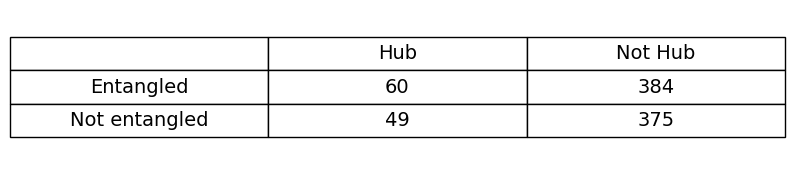

In [50]:
a, b, c, d = 237, 2328, 148, 1160
a, b, c, d = 60, 384, 49, 375
contingency_table = pd.DataFrame({"Hub"    : [a, c],
                                  "Not Hub": [b, d]},
                                  index=["Entangled", "Not entangled"])

plt.clf()
fig, ax    = plt.subplots(figsize = (5, 2))
ax.axis("tight")
ax.axis("off")
cell_text  = contingency_table.reset_index().values.tolist()
col_labels = [""] + contingency_table.columns.tolist()
table      = ax.table(cellText=cell_text, colLabels=col_labels, loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(14)  
table.scale(2, 2)  
plt.show()

In [51]:
odds_ratio, fisher_p_value = fisher_exact(contingency_table, alternative = "two-sided")

# print the results of this analysis
print ("The odds ratio is:", "%.2f" %odds_ratio)
print ("The p-value is   :", "%.3f" %fisher_p_value)

The odds ratio is: 1.20
The p-value is   : 0.413
